In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
train_df = pd.read_csv("emnist-byclass-train.csv")
test_df = pd.read_csv("emnist-byclass-test.csv")

print(train_df.shape)
print(test_df.shape)

(697931, 785)
(116322, 785)


In [3]:
y_train = train_df.iloc[:, 0].values
x_train = train_df.iloc[:, 1:].values

y_test = test_df.iloc[:, 0].values
x_test = test_df.iloc[:, 1:].values

print(x_train.shape, y_train.shape)

(697931, 784) (697931,)


In [4]:
x_train = x_train.reshape(-1, 28, 28)
x_test = x_test.reshape(-1, 28, 28)

print(x_train.shape)

(697931, 28, 28)


In [5]:
x_train = np.transpose(x_train, (0, 2, 1))
x_train = np.flip(x_train, axis=2)

x_test = np.transpose(x_test, (0, 2, 1))
x_test = np.flip(x_test, axis=2)

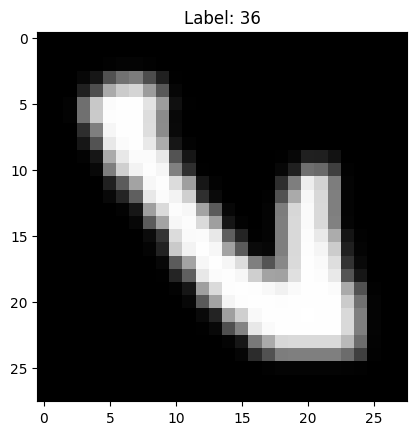

In [8]:
plt.imshow(x_train[988], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [9]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(x_train.shape)

(697931, 28, 28, 1)


In [10]:
x_train = x_train[:120000]
y_train = y_train[:120000]

In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

num_classes = 62

model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

C:\Users\manan lad\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 26, 26, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 11, 11, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 3, 3, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 1, 1, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 62)                  │          15,934 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 142,526 (556.74 KB)

 Trainable params: 142,078 (554.99 KB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 90s 103ms/step - accuracy: 0.5907 - loss: 1.5752 - val_accuracy: 0.7971 - val_loss: 0.6072
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 141s 102ms/step - accuracy: 0.7860 - loss: 0.6462 - val_accuracy: 0.8172 - val_loss: 0.5404
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 99ms/step - accuracy: 0.8090 - loss: 0.5606 - val_accuracy: 0.8222 - val_loss: 0.5146
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 87s 103ms/step - accuracy: 0.8179 - loss: 0.5225 - val_accuracy: 0.8283 - val_loss: 0.5006
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 88s 104ms/step - accuracy: 0.8255 - loss: 0.4948 - val_accuracy: 0.8242 - val_loss: 0.5065
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 85s 101ms/step - accuracy: 0.8316 - loss: 0.4744 - val_accuracy: 0.8358 - val_loss: 0.4802
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 86s 102ms/step - accuracy: 0.8362 - loss: 0.4547 - val_accuracy: 0.8372 - val_loss: 0.4791
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 89s 105ms/step - accuracy: 0.8363 - loss: 0

In [14]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

3636/3636 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.8376 - loss: 0.4675
Test Accuracy: 0.8372018933296204


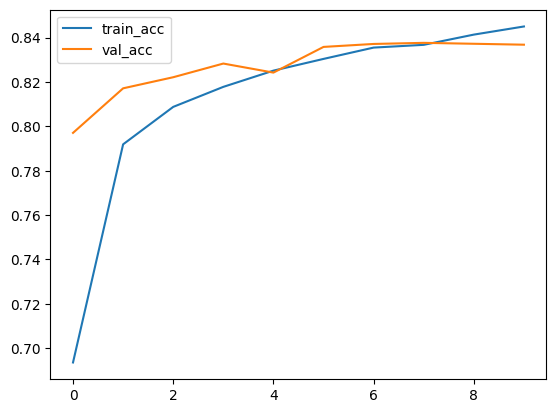

In [15]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

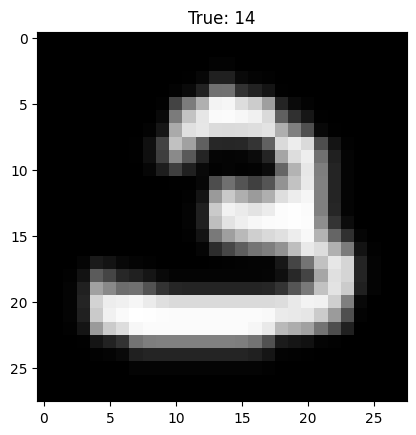

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
Predicted: 14


In [16]:
import random

idx = random.randint(0, len(x_test)-1)

plt.imshow(x_test[idx].squeeze(), cmap='gray')
plt.title(f"True: {y_test[idx]}")
plt.show()

pred = model.predict(x_test[idx].reshape(1,28,28,1))
print("Predicted:", np.argmax(pred))